# Netflix Recommendation System Using SVD

## Project Overview

This project develops a personalized movie recommendation system using collaborative filtering and Singular Value Decomposition (SVD).

The project uses Netflix rating data to learn user–movie rating patterns and generate personalized movie recommendations.

The workflow includes:

- Loading the Netflix ratings data
- Exploring the dataset
- Processing movie and customer information
- Cleaning the rating data
- Filtering movies and customers
- Creating a user–movie rating matrix
- Training an SVD-based recommendation model
- Evaluating the model using RMSE and MAE
- Generating personalized movie recommendations
- Mapping recommended movie IDs to movie titles

## Objective

The main objective is to build a recommendation system that can estimate how highly a user may rate movies they have not previously rated.

The trained SVD model is then used to generate a ranked list of personalized movie recommendations for a selected user.

## Recommendation Approach

This project uses **collaborative filtering**.

The system learns from historical user–movie ratings and identifies patterns in user preferences.

**SVD (Singular Value Decomposition)** is used to model the interaction between users and movies and predict ratings for movies that a user has not previously rated.

## Project Workflow

1. Load the Netflix datasets
2. Explore the rating and movie data
3. Process the Netflix rating format
4. Clean and filter the data
5. Prepare the recommendation-system dataset
6. Train the SVD model
7. Evaluate model performance using cross-validation
8. Generate predicted ratings
9. Rank movies according to predicted ratings
10. Generate personalized recommendations for a user

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Dataset & Data Preprocessing

The project uses Netflix movie-rating data together with a movie-title dataset.

The main datasets used are:

- `combined_data_1.txt` — contains customer ratings and movie information.
- `movie_titles.csv` — contains movie IDs, release years, and movie names.

### Netflix Rating Data

The ratings data is stored in a structured format where a movie ID is followed by the customer ratings associated with that movie.

The preprocessing step identifies the movie associated with each rating and creates a `Movie_Id` column.

The resulting rating data contains information about:

- Customer ID
- Rating
- Movie ID

### Data Cleaning

The dataset is cleaned before building the recommendation system.

The preprocessing includes:

1. Identifying movie boundaries in the ratings file.
2. Assigning the corresponding movie ID to each rating.
3. Removing rows with missing rating information.
4. Filtering movies based on the number of available ratings.
5. Filtering customers based on their rating activity.

These steps reduce sparsity and prepare the data for collaborative filtering.

### Movie Metadata

The movie-title dataset provides additional information about each movie, including:

- Movie ID
- Release year
- Movie name

The movie metadata is later used to convert recommended movie IDs into readable movie titles.

### Rating Data

The cleaned dataset is used to create the user–movie rating structure required for collaborative filtering and SVD-based recommendation.

The final processed data is then used for model training and personalized recommendation generation.

In [2]:
# uploading the dataset
df=pd.read_csv(r"C:\Users\tg_mu\Data Science\GitHub\Netflix Recommendation System\combined_data_1.txt",header=None,names=['Cust_Id','Rating'],usecols=[0,1])

In [3]:
df.shape # shape of the dataset

(24058263, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058263 entries, 0 to 24058262
Data columns (total 2 columns):
 #   Column   Dtype  
---  ------   -----  
 0   Cust_Id  object 
 1   Rating   float64
dtypes: float64(1), object(1)
memory usage: 367.1+ MB


In [5]:
df.head() # top 5 rows of the dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure of the Netflix rating data and the distribution of user interactions with movies.

The analysis examines:

- Number of movies
- Number of customers
- Number of ratings
- Rating distribution
- Movie rating frequency
- Customer rating activity

### Rating Distribution

The distribution of ratings helps understand how users rate movies and whether certain rating values occur more frequently than others.

Understanding the rating distribution is important for a collaborative filtering system because the SVD model learns patterns from historical user ratings.

### Movie Activity

The dataset contains movies with different numbers of ratings.

Movies with very few ratings provide limited information for learning reliable user preference patterns. Therefore, the project filters less-rated movies during preprocessing.

### Customer Activity

Customers also have different levels of rating activity.

Highly inactive customers provide limited information for collaborative filtering. Therefore, customers with insufficient rating activity are filtered from the dataset.

### EDA Objective

The purpose of this analysis is to understand the rating data before constructing the user–movie interaction matrix and training the recommendation model.

In [6]:
# get movie count by counting nan values 
movie_count=df.isnull().sum()[1]

C:\Users\tg_mu\AppData\Local\Temp\ipykernel_14200\228018781.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  movie_count=df.isnull().sum()[1]


In [7]:
movie_count # total 4499 movies

np.int64(4499)

In [8]:
# counting the customers
cust_count=df['Cust_Id'].nunique()-movie_count

In [9]:
cust_count # total 470758 customers

np.int64(470758)

In [10]:
# counting the total ratings
rating_count=df['Cust_Id'].count()-movie_count

In [11]:
rating_count # total 24053764 ratings

np.int64(24053764)

In [12]:
# grouping the ratings by counting 
df_rating=df.groupby('Rating')['Rating'].agg(['count'])

In [13]:
df_rating

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


### To plot the distribution of the ratings in as a bar plot

C:\Users\tg_mu\AppData\Local\Temp\ipykernel_14200\2643838758.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(df_rating.iloc[i-1][0]/4,i-1,'Rating {}:{:.0f}%'.format(i,df_rating.iloc[i-1][0]*100/df_rating.sum()[0]),color='white',weight='bold')


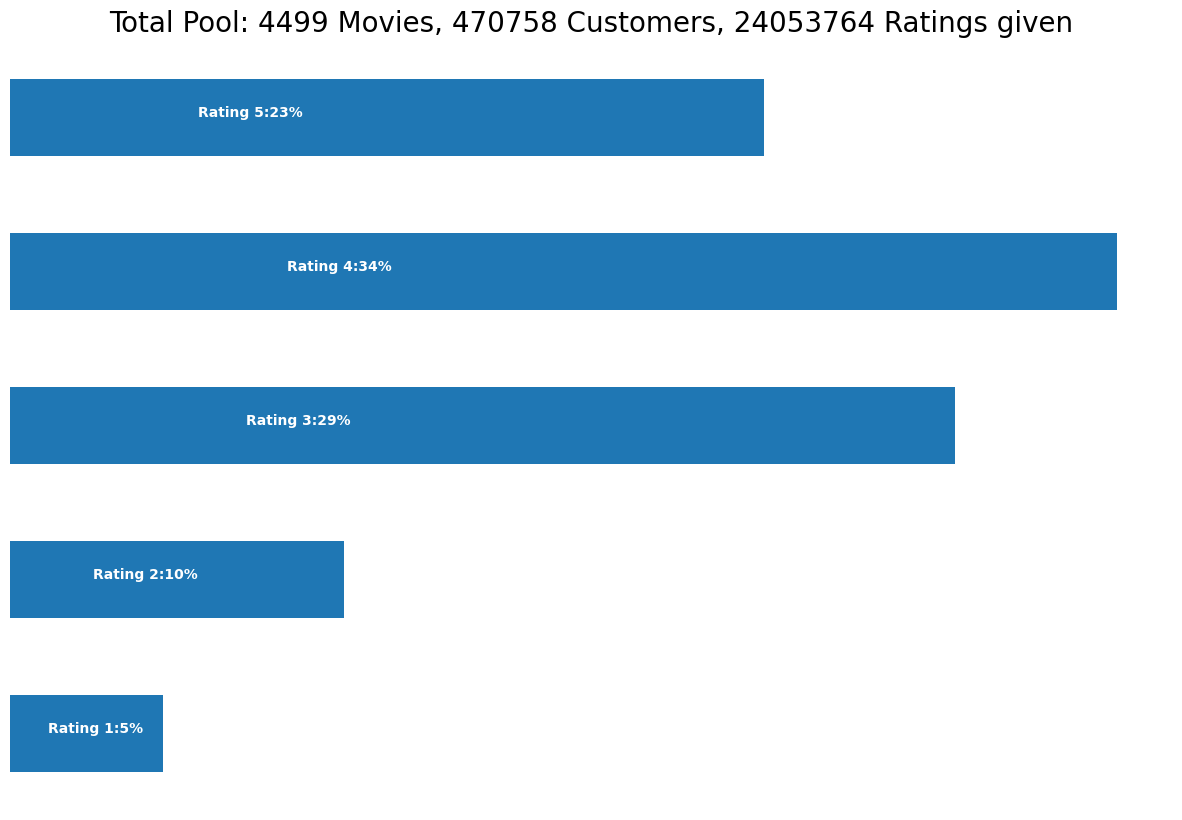

In [14]:
ax=df_rating.plot(kind='barh',legend=False,figsize=(15,10))
plt.title(f'Total Pool: {movie_count} Movies, {cust_count} Customers, {rating_count} Ratings given',fontsize=20)
plt.axis('off')

for i in range(1,6):
    ax.text(df_rating.iloc[i-1][0]/4,i-1,'Rating {}:{:.0f}%'.format(i,df_rating.iloc[i-1][0]*100/df_rating.sum()[0]),color='white',weight='bold')

### To create a numpy array containing movie ids corresponding to the rows in the 'ratings' dataset

In [15]:
df[df['Cust_Id'].str.endswith(":")]

,Cust_Id,Rating
0,1:,NaN
548,2:,NaN
694,3:,NaN
2707,4:,NaN
2850,5:,NaN
...,...,...
24046714,4495:,NaN
24047329,4496:,NaN
24056849,4497:,NaN
24057564,4498:,NaN


In [16]:
# To count all the 'nan' values in the Ratings column in the 'ratings' dataset
df_nan=pd.DataFrame(pd.isnull(df['Rating']))

In [17]:
# To store the index of all the rows containing 'nan' values
df_nan=df_nan[df_nan['Rating']==True]

In [18]:
# To reset the index of the dataframe
df_nan.reset_index(inplace=True)

In [19]:
df_nan

,index,Rating
0,0,True
1,548,True
2,694,True
3,2707,True
4,2850,True
...,...,...
4494,24046714,True
4495,24047329,True
4496,24056849,True
4497,24057564,True


In [20]:
#To create a numpy array containing movie ids according the 'ratings' dataset
movie_np=[]
movie_id=1

for i,j in zip(df_nan['index'][1:],df_nan['index'][:-1]):
    temp=np.full((1,i-j-1),movie_id)
    # numpy approach
    movie_np=np.append(movie_np,temp)
    movie_id +=1

# Account for last record and corresponding length
# numpy approach
last_record=np.full((1,len(df)-df_nan.iloc[-1,0]-1),movie_id)
movie_np=np.append(movie_np,last_record)

print(f'Movie_Numpy:{movie_np}')
print(f'Length:{len(movie_np)}')

Movie_Numpy:[1.000e+00 1.000e+00 1.000e+00 ... 4.499e+03 4.499e+03 4.499e+03]
Length:24053764


In [21]:
#To append the above created array to the datset after removing the 'nan' rows
df=df[pd.notnull(df['Rating'])]
df['Movie_Id']=movie_np.astype(int)
df['Cust_Id']=df['Cust_Id'].astype(int)
print('-Dataset examples-')
df.head()

-Dataset examples-


,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


In [22]:
df.shape

(24053764, 3)

# Data Cleaning

In [23]:
#To create a list of all the movies rated less often(only include top 30% rated movies)
df_movie_summary=df.groupby('Movie_Id')['Rating'].agg(['count','mean'])

df_movie_summary.index=df_movie_summary.index.map(int)

movie_benchmark=round(df_movie_summary['count'].quantile(0.7),0)

drop_movie_list=df_movie_summary[df_movie_summary['count'] < movie_benchmark].index

print('Movie minimum times of review: {}'.format(movie_benchmark))

Movie minimum times of review: 1799.0


In [24]:
#To create a list of all the inactive users(users who rate less often)
df_cust_summary=df.groupby('Cust_Id')['Rating'].agg(['count','mean'])

df_cust_summary.index=df_cust_summary.index.map(int)

cust_benchmark=round(df_cust_summary['count'].quantile(0.7),0)

drop_cust_list=df_cust_summary[df_cust_summary['count'] < cust_benchmark].index

print(f'Customer minimum times of review: {cust_benchmark}')

Customer minimum times of review: 52.0


In [25]:
df=df[~df['Movie_Id'].isin(drop_movie_list)]
df=df[~df['Cust_Id'].isin(drop_cust_list)]

In [26]:
print('-Data Examples-')
df.head()

-Data Examples-


,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3


In [27]:
df.shape

(17337458, 3)

# Create ratings matrix for 'ratings' matrix with Rows = userId, Columns = movieId

In [28]:
df_p=pd.pivot_table(df,values='Rating',index='Cust_Id',columns='Movie_Id')

print(df_p.shape)

(143458, 1350)


## 4. User–Movie Rating Matrix & Collaborative Filtering

A collaborative filtering approach is used to learn relationships between customers and movies based on historical ratings.

### User–Movie Rating Matrix

The cleaned rating data is organized into a user–movie interaction structure where:

- Rows represent customers.
- Columns represent movies.
- Values represent the ratings given by customers.

This structure captures the historical interactions between users and movies.

### Collaborative Filtering

Collaborative filtering recommends items by learning from the preferences and behavior of users.

In this project, the historical movie ratings are used to identify patterns in user preferences.

The model learns these patterns from the available customer–movie rating data and uses them to estimate ratings for movies that a customer has not previously rated.

### Data Preparation for SVD

The processed rating data is prepared in the format required by the `Surprise` recommendation-system library.

The relevant fields are:

- Customer ID
- Movie ID
- Rating

These interactions are then used to train the SVD recommendation model.

### Why Collaborative Filtering?

Collaborative filtering is suitable for this project because the Netflix dataset contains a large number of historical user–movie ratings.

Instead of relying only on movie metadata, the recommendation system learns from the rating behavior of users.

In [29]:
df_p.head()

Movie_Id,3,8,16,17,18,26,28,30,32,33,...,4472,4474,4478,4479,4485,4488,4490,4492,4493,4496
Cust_Id,,,,,,,,,,,,,,,,,,,,,
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,5.0,NaN,NaN,NaN,NaN,4.0,5.0,NaN,NaN,...,3.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
134,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### To load the movie_titles dataset

In [30]:
df_title=pd.read_csv('movie_titles.csv',encoding='ISO-8859-1', header=None,names=['Movie_Id','Year','Name'],usecols=[0,1,2])

df_title.set_index('Movie_Id',inplace=True)

print(df_title.head())

            Year                          Name
Movie_Id                                      
1         2003.0               Dinosaur Planet
2         2004.0    Isle of Man TT 2004 Review
3         1997.0                     Character
4         1994.0  Paula Abdul's Get Up & Dance
5         2004.0      The Rise and Fall of ECW


## 5. SVD Model & Training

The recommendation model is built using **Singular Value Decomposition (SVD)** from the `Surprise` library.

SVD is a matrix-factorization technique that learns latent factors from historical user–movie ratings.

### Model

The model is implemented using:

```python
SVD()

In [32]:
from surprise import Reader,Dataset,SVD
from surprise.model_selection import cross_validate

## 6. SVD Model Evaluation & Results

The SVD recommendation model is evaluated using **3-fold cross-validation**.

Two error metrics are used:

- **RMSE (Root Mean Squared Error)** — measures the magnitude of prediction errors, giving greater weight to larger errors.
- **MAE (Mean Absolute Error)** — measures the average absolute difference between actual and predicted ratings.

For both metrics, lower values indicate better prediction performance.

### Cross-Validation Results

| Metric | Fold 1 | Fold 2 | Fold 3 | Mean | Std |
|---|---:|---:|---:|---:|---:|
| RMSE | 0.9950 | 0.9885 | 1.0060 | **0.9965** | 0.0072 |
| MAE | 0.7974 | 0.7933 | 0.8015 | **0.7974** | 0.0034 |

### Runtime

| Metric | Fold 1 | Fold 2 | Fold 3 | Mean | Std |
|---|---:|---:|---:|---:|---:|
| Fit Time | 0.80 s | 0.82 s | 0.89 s | 0.84 s | 0.04 s |
| Test Time | 0.19 s | 0.11 s | 0.40 s | 0.24 s | 0.12 s |

### Model Performance

Across the three folds, the SVD model achieved:

- **Mean RMSE: 0.9965**
- **Mean MAE: 0.7974**

The relatively small standard deviations indicate that the model's prediction error was fairly consistent across the three folds.

These results provide an estimate of how accurately the SVD model can predict user ratings on the evaluated dataset.

In [33]:
reader=Reader()
svd=SVD()

# get just top 100K rows for faster run time
data=Dataset.load_from_df(df[['Cust_Id','Movie_Id','Rating']][:100000],reader)

# Compute the RMSE,MAE of the SVD algorithm
cross_validate(svd,data,measures=['RMSE','MAE'],cv=3,verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9950  0.9885  1.0060  0.9965  0.0072  
MAE (testset)     0.7974  0.7933  0.8015  0.7974  0.0034  
Fit time          0.80    0.82    0.89    0.84    0.04    
Test time         0.19    0.11    0.40    0.24    0.12    


{'test_rmse': array([0.99503447, 0.98853186, 1.00598996]),
 'test_mae': array([0.79740667, 0.79326547, 0.80153268]),
 'fit_time': (0.8019719123840332, 0.8215405941009521, 0.8859257698059082),
 'test_time': (0.1923668384552002, 0.11403822898864746, 0.39941930770874023)}

In [34]:
df.head()

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3


## 7. Personalized Movie Recommendations

After evaluating the SVD model, the trained recommendation system is used to generate personalized movie recommendations for a selected customer.

### Target User

The recommendations are generated for:

```text
User ID: 712664

## To find all the movies rated as 5 stars by user with userId = 712664

In [35]:
df_712664=df[(df['Cust_Id']== 712664) & (df['Rating'] == 5.0)]

In [36]:
df_712664.set_index('Movie_Id',inplace=True)

In [37]:
df_712664.head()

,Cust_Id,Rating
Movie_Id,,
3,712664,5.0
79,712664,5.0
175,712664,5.0
199,712664,5.0
241,712664,5.0


In [38]:
df_712664=df_712664.join(df_title)['Name']

In [39]:
df_712664

Movie_Id
3                       Character
79                    The Killing
175                Reservoir Dogs
199               The Deer Hunter
241            North by Northwest
                  ...            
3887    Aguirre: The Wrath of God
4109              American Psycho
4266    The Passion of the Christ
4384             Dawn of the Dead
4392             Army of Darkness
Name: Name, Length: 84, dtype: object

## Train an SVD to predict ratings for user with userId = 712664

In [40]:
# Create a shallow copy for the movies dataset
user_712664=df_title.copy()
user_712664=user_712664.reset_index()

In [41]:
user_712664

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [42]:
#To remove all the movies rated less often
user_712664=user_712664[~user_712664['Movie_Id'].isin(drop_movie_list)]

In [43]:
# getting full dataset
data=Dataset.load_from_df(df[['Cust_Id','Movie_Id','Rating']],reader)

#create a training set for svd
trainset=data.build_full_trainset()
svd.fit(trainset)

In [44]:
#Predict the ratings for user_712664
user_712664['Estimate_Score']=user_712664['Movie_Id'].apply(lambda x: svd.predict(712664,x).est)

C:\Users\tg_mu\AppData\Local\Temp\ipykernel_14200\174719316.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_712664['Estimate_Score']=user_712664['Movie_Id'].apply(lambda x: svd.predict(712664,x).est)


In [45]:
#Drop extra columns from the user_712664 data frame
user_712664 = user_712664.drop('Movie_Id', axis = 1)


# Sort predicted ratings for user_712664 in descending order
user_712664=user_712664.sort_values('Estimate_Score',ascending=False)

#Print top 10 recommendations
print(user_712664.head(10))

        Year                                      Name  Estimate_Score
773   2003.0                        Foyle's War: Set 2        5.000000
3927  2004.0                        Nip/Tuck: Season 2        5.000000
174   1992.0                            Reservoir Dogs        5.000000
2404  2003.0                              MI-5: Vol. 2        5.000000
1847  1956.0  Samurai Trilogy 3: Duel at Ganryu Island        5.000000
4352  2002.0            Curb Your Enthusiasm: Season 3        5.000000
721   2003.0                        The Wire: Season 1        5.000000
871   1954.0                             Seven Samurai        5.000000
3289  1974.0                             The Godfather        5.000000
995   1961.0                                   Yojimbo        4.995507


## 8. Recommendation Analysis & Conclusion

### Recommendation Analysis

The SVD model generates personalized movie recommendations by predicting ratings for movies that the selected user has not previously rated.

For user `712664`, the model produced several movies with estimated ratings close to or equal to the maximum rating of 5.0.

The top recommendations include:

- Foyle's War: Set 2
- Nip/Tuck: Season 2
- Reservoir Dogs
- MI-5: Vol. 2
- Samurai Trilogy 3: Duel at Ganryu Island
- Curb Your Enthusiasm: Season 3
- The Wire: Season 1
- Seven Samurai
- The Godfather
- Yojimbo

These recommendations represent the movies with the highest predicted ratings from the SVD model for the selected user.

### Key Findings

- The recommendation system uses collaborative filtering based on historical user–movie ratings.
- SVD was used to learn latent patterns in the rating data.
- The model achieved a mean **RMSE of 0.9965** across 3 cross-validation folds.
- The model achieved a mean **MAE of 0.7974** across 3 cross-validation folds.
- The relatively small standard deviations indicate consistent results across the three folds.
- Personalized recommendations were successfully generated for user `712664`.
- Several recommended movies received estimated ratings of **5.0**.

### Limitations

The current recommendation system has some limitations:

- The evaluation is based on a sample of the rating data.
- The recommendation model uses only collaborative filtering.
- Cold-start users with little or no rating history may be difficult to recommend for.
- New movies with limited ratings may also be difficult to recommend accurately.
- Predicted ratings are estimates and do not guarantee that a user will actually enjoy a recommended movie.

### Future Improvements

Potential improvements include:

- Hyperparameter tuning of the SVD model.
- Comparing SVD with other collaborative-filtering algorithms.
- Evaluating additional recommendation metrics such as Precision@K and Recall@K.
- Implementing a content-based recommendation approach.
- Building a hybrid recommendation system.
- Handling cold-start users and movies.
- Increasing the amount of training data.
- Developing an interactive recommendation interface.

### Conclusion

This project demonstrates an end-to-end movie recommendation system using collaborative filtering and Singular Value Decomposition.

The workflow covers data loading, Netflix rating preprocessing, exploratory data analysis, data filtering, user–movie interaction preparation, SVD model training, cross-validation, rating prediction, and personalized movie recommendation.

The SVD model achieved a mean RMSE of **0.9965** and a mean MAE of **0.7974** across three cross-validation folds.

The trained model was also used to generate personalized recommendations for user `712664`, demonstrating how collaborative filtering can be used to predict user preferences and rank unseen movies.